# Influential Observations: Cook's Distance, Leverage, and DFFITS

## Overview

An **outlier** has an unusual response value. A **high-leverage point** has an unusual predictor value (far from the centroid of X). An **influential observation** combines both — it has high leverage AND a large residual, meaning it substantially changes the fitted model when removed.

**Key measures:**

| Measure | Formula | Threshold | Detects |
|---|---|---|---|
| **Leverage** (h_ii) | Diagonal of hat matrix | > 2(p+1)/n | Unusual X position |
| **Studentised residual** | e_i / (s_{(i)} √(1-h_ii)) | \|t\| > 2–3 | Unusual Y given X |
| **Cook's D** | Shift in all fitted values | > 4/n or > 1 | Joint influence |
| **DFFITS** | Scaled change in fitted value_i | \|DFFITS\| > 2√(p/n) | Influence on own prediction |
| **DFBETAS** | Change in each coefficient | \|DFBETA\| > 2/√n | Influence on specific coef |

**Philosophy:** Influential observations are not automatically errors. They may represent genuine extreme conditions, data entry errors, or the most scientifically interesting cases. The goal is to *identify and understand* them — not to automatically delete them.

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(broom)
library(car)           # influencePlot(), outlierTest(), infIndexPlot()
library(patchwork)

set.seed(42)

n <- 120
inf_data <- tibble(
  nitrate    = runif(n, 1, 10),
  water_qual = 9 - 0.5*nitrate + rnorm(n, 0, 1),
  richness   = 24 - 1.8*nitrate + 0.7*water_qual + rnorm(n, 0, 2)
)

# Add deliberate influential observations
inf_data <- bind_rows(
  inf_data,
  # High leverage + large residual (influential)
  tibble(nitrate=15, water_qual=1.5, richness=35),
  # High leverage + small residual (not influential)
  tibble(nitrate=14, water_qual=1.2, richness=3),
  # Low leverage + large residual (outlier, less influential)
  tibble(nitrate=5, water_qual=5.5, richness=45)
)

lm_fit <- lm(richness ~ nitrate + water_qual, data=inf_data)
aug    <- broom::augment(lm_fit) %>%
  mutate(obs_id=row_number())

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'broom' was built under R version 4.4.3"
Warning message:
"package 'car' was built under R version 4.4.3"
L

---

## Computing and Visualising Influence Measures

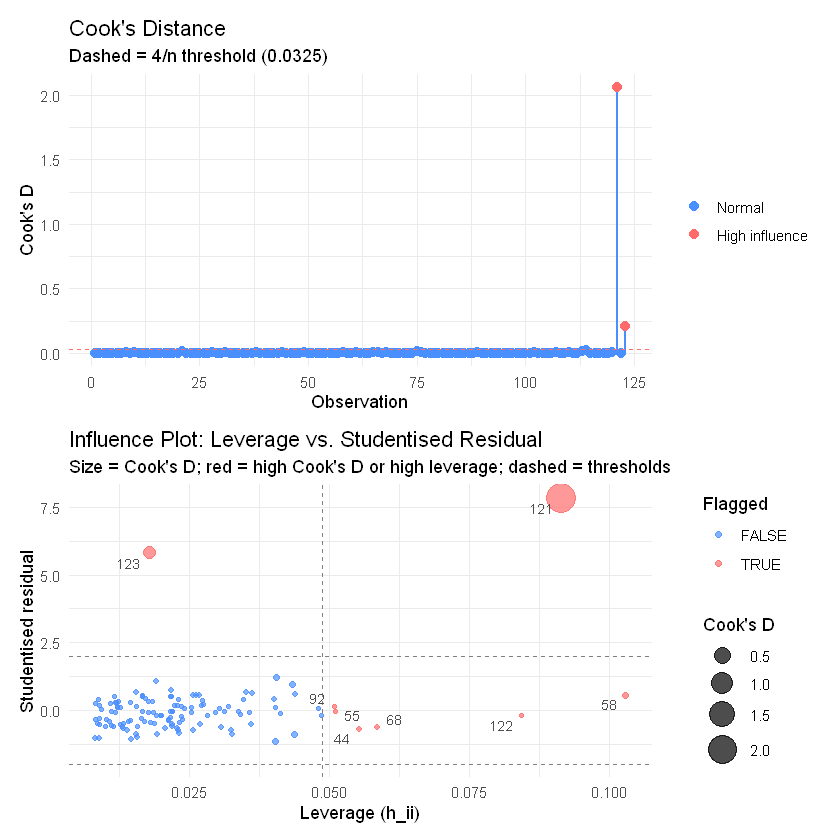

In [2]:
n_obs <- nrow(inf_data)
p     <- length(coef(lm_fit)) - 1  # number of predictors

inf_measures <- aug %>%
  mutate(
    leverage     = .hat,
    cooksd       = .cooksd,
    std_resid    = .std.resid,
    dffits       = dffits(lm_fit),
    lev_thresh   = 2*(p+1)/n_obs,
    cook_thresh  = 4/n_obs,
    high_lev     = leverage > lev_thresh,
    high_cook    = cooksd  > cook_thresh,
    high_resid   = abs(std_resid) > 2
  )

# ── Cook's distance plot ──────────────────────────────────────────────────────
p_cook <- ggplot(inf_measures, aes(x=obs_id, y=cooksd)) +
  geom_segment(aes(xend=obs_id, yend=0), color="#4a8fff", linewidth=0.6) +
  geom_point(aes(color=high_cook), size=2.5) +
  geom_hline(yintercept=4/n_obs, linetype="dashed", color="#ff6b6b") +
  scale_color_manual(values=c("FALSE"="#4a8fff","TRUE"="#ff6b6b"),
                     labels=c("FALSE"="Normal","TRUE"="High influence")) +
  labs(title="Cook's Distance",
       subtitle=sprintf("Dashed = 4/n threshold (%.4f)", 4/n_obs),
       x="Observation", y="Cook's D", color=NULL) +
  theme_minimal()

# ── Leverage vs. studentised residual (influence plot) ───────────────────────
p_inf <- ggplot(inf_measures,
                aes(x=leverage, y=std_resid, size=cooksd,
                    color=high_cook|high_lev)) +
  geom_point(alpha=0.7) +
  geom_hline(yintercept=c(-2,2), linetype="dashed", color="gray50") +
  geom_vline(xintercept=2*(p+1)/n_obs, linetype="dashed", color="gray50") +
  ggrepel::geom_text_repel(
    data=inf_measures %>% filter(high_cook|high_lev|high_resid),
    aes(label=obs_id), size=3, color="gray30"
  ) +
  scale_color_manual(values=c("FALSE"="#4a8fff","TRUE"="#ff6b6b")) +
  scale_size_continuous(range=c(1,8)) +
  labs(title="Influence Plot: Leverage vs. Studentised Residual",
       subtitle="Size = Cook's D; red = high Cook's D or high leverage; dashed = thresholds",
       x="Leverage (h_ii)", y="Studentised residual",
       color="Flagged", size="Cook's D") +
  theme_minimal()

(p_cook / p_inf)

---

## DFBETAS: Influence on Individual Coefficients

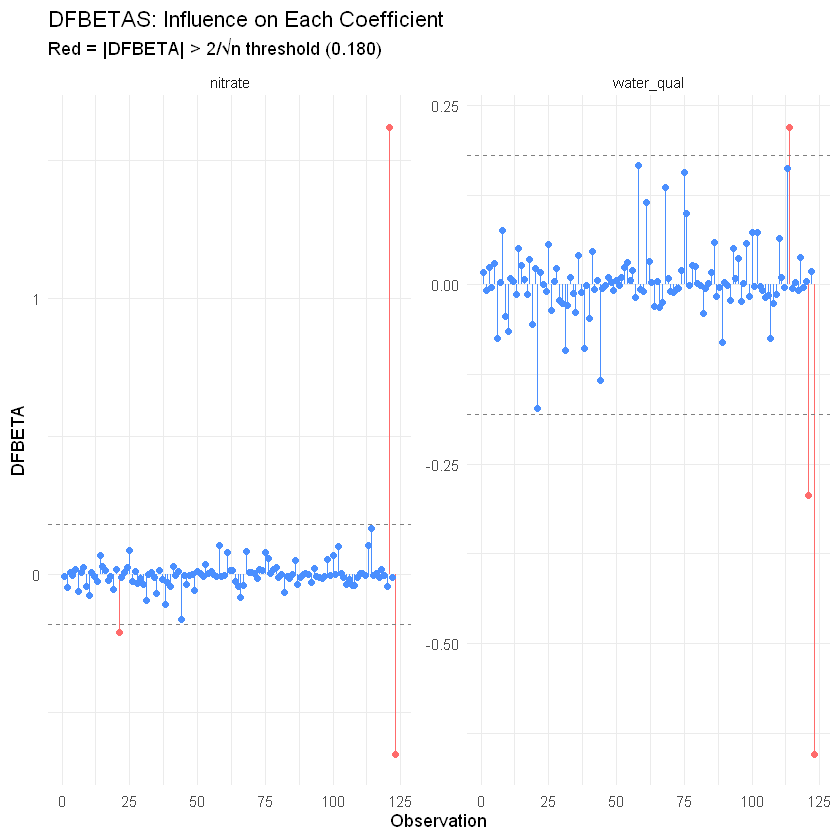

In [3]:
# DFBETAS: how much does each coefficient change if this observation is removed?
dfb <- as_tibble(dfbetas(lm_fit)) %>%
  mutate(obs_id = row_number()) %>%
  pivot_longer(-obs_id, names_to="coefficient", values_to="dfbeta")

thresh_dfb <- 2 / sqrt(n_obs)

ggplot(dfb %>% filter(coefficient != "(Intercept)"),
       aes(x=obs_id, y=dfbeta,
           color=abs(dfbeta) > thresh_dfb)) +
  geom_segment(aes(xend=obs_id, yend=0), linewidth=0.5) +
  geom_point(size=1.5) +
  geom_hline(yintercept=c(-thresh_dfb, thresh_dfb),
             linetype="dashed", color="gray50") +
  facet_wrap(~coefficient, scales="free_y") +
  scale_color_manual(values=c("FALSE"="#4a8fff","TRUE"="#ff6b6b"),
                     guide="none") +
  labs(title="DFBETAS: Influence on Each Coefficient",
       subtitle=sprintf("Red = |DFBETA| > 2/√n threshold (%.3f)", thresh_dfb),
       x="Observation", y="DFBETA") +
  theme_minimal()

---

## What to Do with Influential Observations

In [4]:
# ── Step 1: Identify ──────────────────────────────────────────────────────────
flagged <- inf_measures %>%
  filter(high_cook | (high_lev & high_resid)) %>%
  select(obs_id, nitrate, water_qual, richness, leverage, cooksd, std_resid)
cat("Flagged observations:\n")
print(flagged)

# ── Step 2: Investigate ───────────────────────────────────────────────────────
# For each flagged point: check data entry; consider whether it's a genuine
# extreme case or a measurement/recording error

# ── Step 3: Fit with and without; compare coefficients ───────────────────────
flagged_ids <- flagged$obs_id
lm_without  <- lm(richness ~ nitrate + water_qual,
                  data=inf_data[-flagged_ids,])

coef_compare <- bind_rows(
  broom::tidy(lm_fit)    %>% mutate(model="Full"),
  broom::tidy(lm_without)%>% mutate(model="Without flagged")
) %>%
  filter(term != "(Intercept)") %>%
  select(model, term, estimate, std.error) %>%
  mutate(across(where(is.numeric), ~round(.x, 3)))

print(coef_compare)
# If coefficients change substantially: flagged points are genuinely influential
# Report both models; explain why observations were retained or removed

# ── Step 4: Never silently delete ────────────────────────────────────────────
cat("
Decision framework for influential observations:
  Data error confirmed → correct or remove; document in methods
  Genuine extreme case → retain; report sensitivity analysis
  Unknown cause        → retain; report both models; flag as limitation
  Never: remove without investigation; remove because it improves fit
")

Flagged observations:
# A tibble: 2 × 7
  obs_id nitrate water_qual richness leverage cooksd std_resid
   <int>   <dbl>      <dbl>    <dbl>    <dbl>  <dbl>     <dbl>
1    121      15        1.5       35   0.0914  2.06       7.84
2    123       5        5.5       45   0.0178  0.206      5.84
# A tibble: 4 × 4
  model           term       estimate std.error
  <chr>           <chr>         <dbl>     <dbl>
1 Full            nitrate      -1.69      0.251
2 Full            water_qual    0.141     0.447
3 Without flagged nitrate      -1.83      0.115
4 Without flagged water_qual    0.482     0.203

Decision framework for influential observations:
  Data error confirmed → correct or remove; document in methods
  Genuine extreme case → retain; report sensitivity analysis
  Unknown cause        → retain; report both models; flag as limitation
  Never: remove without investigation; remove because it improves fit


---

## Common Pitfalls

**1. Removing influential observations without investigation**  
An influential observation is statistically unusual, not necessarily wrong. Removing data to improve model fit without checking for a data error or understanding the cause is a form of p-hacking. Always investigate first; document any removal in the methods; report a sensitivity analysis with and without the removed points.

**2. Confusing outliers with influential observations**  
An outlier (large residual) that has average leverage has little influence on the regression line. A point with extreme predictor values (high leverage) but a small residual also has little influence. Only the combination — high leverage and large residual — produces substantial influence. Cook's D captures both dimensions jointly.

**3. Using Cook's D > 1 as the only threshold**  
Cook's D > 1 is the traditional "severe" threshold, but with small n, the more sensitive 4/n threshold flags observations whose removal would change fitted values by a practically meaningful amount. Use 4/n for routine screening and follow up on all flagged points.

**4. Not checking DFBETAS after finding high Cook's D**  
Cook's D measures overall influence on the fitted values. A high Cook's D might affect only one coefficient strongly while leaving others stable. DFBETAS identifies which specific coefficients an observation influences — critical when individual coefficients are being interpreted substantively.

**5. Applying OLS influence diagnostics to GLMs without adjustment**  
Leverage and Cook's D from `augment()` are computed for OLS. For GLMs, use `influence.measures()` on `glm()` objects, or the DHARMa outlier test for GLMMs. The Pearson residual replaces the raw residual in GLM influence calculations.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*